In [1]:
import sqlite3
db_file = "nextbike_data_old.db"

try: 
    conn = sqlite3.connect(db_file)
    conn.row_factory = sqlite3.Row
    cur = conn.cursor()
    cur.execute("SELECT name FROM sqlite_master WHERE type='table';")
    tables = [r["name"] for r in cur.fetchall()]
    print(f"Connected to {db_file} - tables: {tables or '(<no tables>)'}")
except sqlite3.Error as e:
    print("SQLite error:", e)
    conn = None
    cur = None

Connected to nextbike_data_old.db - tables: ['api_data', 'sqlite_sequence', 'bike_locations', 'stations', 'city_summaries', 'scraping_metadata']


In [5]:
import pandas as pd
query = 'SELECT * FROM city_summaries;'

table = pd.read_sql_query(query, conn)
table.head(5)

,id,scrape_id,timestamp,city_uid,city_name,country_name,total_bikes,available_bikes,booked_bikes,set_point_bikes,num_places
0,1,1,2025-09-14 20:38:04.515959,21,Karlsruhe,Germany,857,535,19,857,567
1,2,2,2025-09-14 20:43:04.805354,21,Karlsruhe,Germany,857,537,17,857,568
2,3,3,2025-09-14 20:48:05.107732,21,Karlsruhe,Germany,857,543,20,857,567
3,4,4,2025-09-14 20:53:05.970129,21,Karlsruhe,Germany,857,541,19,857,565
4,5,5,2025-09-14 20:58:06.766290,21,Karlsruhe,Germany,857,534,23,857,566


In [9]:
query_top5 = """
SELECT booked_bikes, available_bikes, total_bikes, timestamp
FROM city_summaries
ORDER BY timestamp DESC
LIMIT 20;
"""

top5 = pd.read_sql_query(query_top5, conn)
top5


,booked_bikes,available_bikes,total_bikes,timestamp
0,17,527,837,2025-10-08 08:40:59.301451
1,14,532,836,2025-10-08 08:35:58.913749
2,15,524,836,2025-10-08 08:30:58.648926
3,11,528,836,2025-10-08 08:25:58.339287
4,13,533,836,2025-10-08 08:20:57.872481
5,10,530,835,2025-10-08 08:15:57.603742
6,11,526,835,2025-10-08 08:10:57.311934
7,14,527,835,2025-10-08 08:05:56.988888
8,16,531,841,2025-10-08 08:00:56.715494
9,18,523,841,2025-10-08 07:55:55.417783


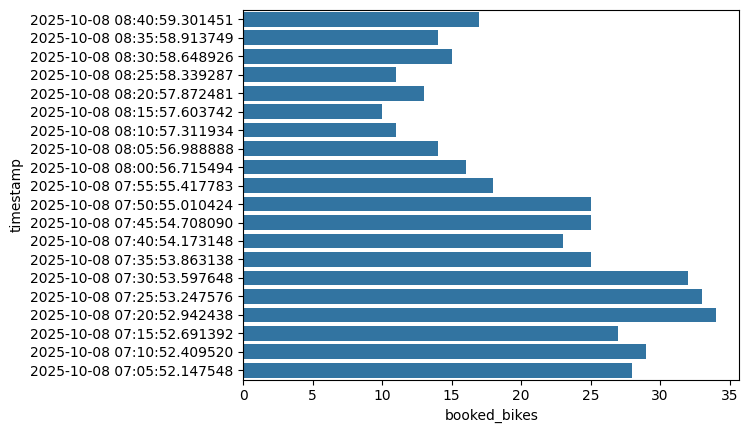

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(data=top5, x="booked_bikes", y="timestamp")
plt.show()